In [1]:
import matplotlib.pyplot as plt
import distinctipy
import numpy as np 
import pandas as pd 
import os 
import pickle
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'

In [2]:
def std_err(arr):
    err = np.nanstd(arr,axis=0)/np.sqrt(np.sum(~np.isnan(arr),axis=0))
    return err

def pval_to_asterisks(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


In [72]:
# from scipy.stats import dunnett 
def make_pivot(df):
    mean_df_figC = (
        df.groupby(['retinal', 'light'])['PER']
        .mean()
        .reset_index()
        .rename(columns={'PER': 'mean PER'})
    )

    std_df_figC = (
        df.groupby(['retinal', 'light'])['PER']
        .sem()
        .reset_index()
        .rename(columns={'PER': 'ste PER'})
    )

    df_pivot_figC = mean_df_figC.pivot(index='light', columns='retinal', values='mean PER')

    # 컬럼 이름 변경 (선택)
    df_pivot_figC.columns = ['retinal (-)', 'retinal (+)']

    err_pivot_figC = std_df_figC.pivot(index='light', columns='retinal', values='ste PER')
    err_pivot_figC.columns = ['retinal (-)', 'retinal (+)']

    data_df_figC = {}
    for i,d in df.groupby(['light', 'retinal'])['PER']:
        data_df_figC[i] = d 

    return data_df_figC,df_pivot_figC,err_pivot_figC





def draw_figure(data_df_figC,df_pivot_figC,err_pivot_figC):
    bar_width = .25
    bar_spacing = .7
    lp = 1
    fontsize = 7
    num_bars = 4

    x_loc = np.arange(0, num_bars *bar_spacing, bar_spacing)  # 예: 6 간격으로 설
    cmap = ['#AEACAB','black']
    # 그룹 막대 그리기
    ax.bar(x_loc - bar_width / 2, list(df_pivot_figC['retinal (-)']), yerr=list(err_pivot_figC['retinal (-)']), width=bar_width, label='retinal (-)', color=cmap[0],edgecolor='black',linewidth=.5,capsize=2,error_kw=dict(elinewidth=.5,capthick=.5))
    ax.bar(x_loc + bar_width / 2, list(df_pivot_figC['retinal (+)']), yerr=list(err_pivot_figC['retinal (+)']), width=bar_width, label='retinal (+)', color=cmap[1],edgecolor='black',linewidth=.5,capsize=2,error_kw=dict(elinewidth=.5,capthick=.5))

    ax.set_xticks(x_loc,['-','+','-','+'],rotation=0,fontsize=fontsize)    
    yticks = np.round(np.arange(0,1.25,.25),2)
    ax.set_yticks(yticks,yticks,fontsize=fontsize)
    ax.legend(fontsize=fontsize,bbox_to_anchor=(1.05,1))
    ax.set_ylabel('Tarsal PER',fontsize=fontsize,labelpad=lp)
    # ax.set_xlabel('Retinal',fontsize=fontsize,labelpad=lp)


    colors = ['#AEACAB','white']
    combs = {0:[0,1],1:[0,1],2:[2,3],3:[2,3]}
    for i, cond in enumerate(combs.keys()):

        x_base = x_loc[i]
        for group_idx,group in enumerate(combs[cond]):
    #         group = cond_group[1]
            print((cond,group))
            values = np.array(data_df_figC[(cond,group)])

            values = values[~np.isnan(values)]

            x_loc_per_v = {}
            x_jittered=[]
            v_unique,v_counts = np.unique(values,return_counts=True)
            for v in v_unique:
                n = v_counts[v_unique==v][0]
                step = bar_width/(n+1)
                direction = (-1)**(group_idx+1)
                for s in range(1,n+1):
                    x_jittered.append(x_base + direction*step*s)
            values_resorted = np.concatenate([np.repeat(x,c) for x,c in zip(v_unique,v_counts)])
            print(tuple(zip(x_jittered,values_resorted)))

            ax.scatter(
                x_jittered,
                values_resorted,
                color='white',#colors[group_idx],
                edgecolor='black',
                linewidth=0.3,
                s=7.5,
                zorder=10,
                alpha=0.9
            )
    ax.get_legend().remove()
#     ax.set_xlim([-.4,3.1])
    ax.set_ylim([0,.85])
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    dunn = wilcoxon(data_all[(0,1)],data_all[(1,1)],alternative='greater')#dunnett(*[list(data_df_figC[c]) for c in [(1,1)]],control=list(data_df_figC[0,1]))
    pval = dunn.pvalue
#     asts = [pval_to_asterisks(p) for p in pval]   

    x1 = x_loc[0]+bar_width/2
    x2 = x_loc[1]+bar_width/2
    y = np.max(data_df_figC[(0,1)])+.05
    h=.05
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], c='k')
    ax.text((x1+x2)*.5, y+h, pval_to_asterisks(pval), ha='center', va='bottom', color='k',fontsize=7)   
        
    dunn = wilcoxon(data_all[(2,3)],data_all[(3,3)],alternative='greater')#dunnett(*[list(data_df_figC[c]) for c in [(3,3)]],control=list(data_df_figC[2,3]))
    pval = dunn.pvalue
#     asts = [pval_to_asterisks(p) for p in pval]   

    x1 = x_loc[2]+bar_width/2
    x2 = x_loc[3]+bar_width/2
    y = np.max(data_df_figC[(0,1)])+.05
    h=.05
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], c='k')
    ax.text((x1+x2)*.5, y+h, pval_to_asterisks(pval), ha='center', va='bottom', color='k',fontsize=7)   
        
        
        
        
    sucrose = ['+','+','+','+']
    light = ['-','+','-','+']
    x_loc_all = np.sort(np.concatenate([x_loc - bar_width / 2,x_loc + bar_width / 2]))
    ax.set_xticks([np.mean(x_loc_all)],[])
    
    
    y_offset = -.15
    ax.text(-.5,y_offset,'suc.',fontsize=fontsize,ha='right',va='top')
    ax.text(-.5,y_offset*2,'red lit.',fontsize=fontsize,ha='right',va='top')
    for i,x in enumerate(x_loc):
        ax.text(x,y_offset,sucrose[i],fontsize=fontsize,ha='center',va='top')
        ax.text(x,y_offset*2,light[i],fontsize=fontsize,ha='center',va='top')


    


In [73]:
fpath = '/volume_4/research/seongbong/flywire/geosmin_project/LM_data_from_dilan/experiment/inhibitory_neuron_optogenetics/optogenetics_geosmin_pathway_251119.xlsx'

sheets = pd.ExcelFile(fpath)
sheets = sheets.sheet_names
data_df = {}
for s in sheets:
    df = pd.read_excel(fpath,s)
    data_df[s] = df

In [74]:
data_all = []
pivot_all = []
error_all = []
for s in ['LH1989','LH1990']:
    this_df = data_df[s]
    data,pivot,error =make_pivot(this_df)
    data_all.append(data)
    pivot_all.append(pivot)
    error_all.append(error)
#     fig,ax = plt.subplots(1,1,figsize=(2,1.8))
#     draw_figure(data,pivot,error)
#     name = f"{s.split(' ')[-1]}>ReachR"
#     ax.set_title(name,fontsize=fontsize,fontstyle='italic')
#     plt.savefig(f'/volume_4/research/seongbong/flywire/geosmin_project/figure/figure6/optogenetics_inhibitory_neurons/figures/{s}.svg',bbox_inches='tight')

In [75]:
data_all = {**data_all[0],**{(x[0]+2,x[1]+2):y for x,y in data_all[1].items()}}

pivot_all = pd.concat(pivot_all)
pivot_all.reset_index(inplace=True)

error_all = pd.concat(error_all)
error_all.reset_index(inplace=True)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

(0, 0)
((-0.125, 0.3), (-0.125, 0.4), (-0.125, 0.5), (-0.125, 0.6), (-0.08333333333333333, 0.8), (-0.16666666666666666, 0.8))
(0, 1)
((0.0625, 0.5), (0.125, 0.5), (0.1875, 0.5), (0.125, 0.6), (0.125, 0.7), (0.125, 0.9))
(1, 0)
((0.575, 0.3), (0.575, 0.4), (0.575, 0.5), (0.575, 0.6), (0.575, 0.7), (0.575, 0.9))
(1, 1)
((0.825, 0.0), (0.7625, 0.2), (0.825, 0.2), (0.8875, 0.2), (0.825, 0.3), (0.825, 0.5))
(2, 2)
((1.275, 0.5), (1.3166666666666667, 0.6), (1.2333333333333332, 0.6), (1.275, 0.7), (1.275, 0.8))
(2, 3)
((1.525, 0.5), (1.4625, 0.6), (1.525, 0.6), (1.5875, 0.6), (1.525, 0.7))
(3, 2)
((1.9749999999999996, 0.5), (1.9749999999999996, 0.6), (2.0374999999999996, 0.7), (1.9749999999999996, 0.7), (1.9124999999999996, 0.7))
(3, 3)
((2.183333333333333, 0.2), (2.266666666666666, 0.2), (2.2249999999999996, 0.3), (2.2249999999999996, 0.4), (2.2249999999999996, 0.5))


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

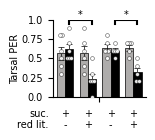

In [78]:
from scipy.stats import wilcoxon
fig,ax = plt.subplots(1,1,figsize=(1.2,1))

draw_figure(data_all,pivot_all,error_all)
ax.set_ylim([0,1])
plt.savefig(f'optogenetic_activation_LHav1a1_merged_with_stat_251119.svg',bbox_inches='tight')

In [82]:
pivot_all

,light,retinal (-),retinal (+)
0,0,0.566667,0.616667
1,1,0.566667,0.233333
2,0,0.640000,0.600000
3,1,0.640000,0.320000
